<a href="https://githubtocolab.com/tannialhernandez/topicosAvanzadosAnalitica/blob/main/SecondPart/E2-SentimentAnalysis/E1_SentimentPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

## Analyze how travelers expressed their feelings on Twitter

A sentiment analysis job about the problems of each major U.S. airline.
Twitter data was scraped from February of 2015 and contributors were
asked to first classify positive, negative, and neutral tweets, followed
by categorizing negative reasons (such as "late flight" or "rude service").

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

# read the data and set the datetime as the index
tweets = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/Tweets.zip', index_col=0)

tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [2]:
tweets.shape

(14640, 14)

### Proportion of tweets with each sentiment

In [3]:
tweets['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


### Proportion of tweets per airline


In [4]:
tweets['airline'].value_counts()

,count
airline,
United,3822
US Airways,2913
American,2759
Southwest,2420
Delta,2222
Virgin America,504


<Axes: xlabel='airline'>

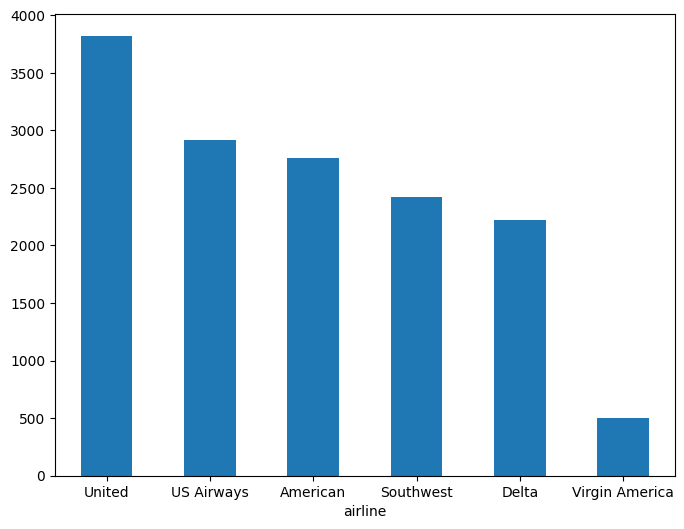

In [5]:
pd.Series(tweets["airline"]).value_counts().plot(kind = "bar",figsize=(8,6),rot = 0)

<Axes: title={'center': 'Sentiment by airline'}, xlabel='airline'>

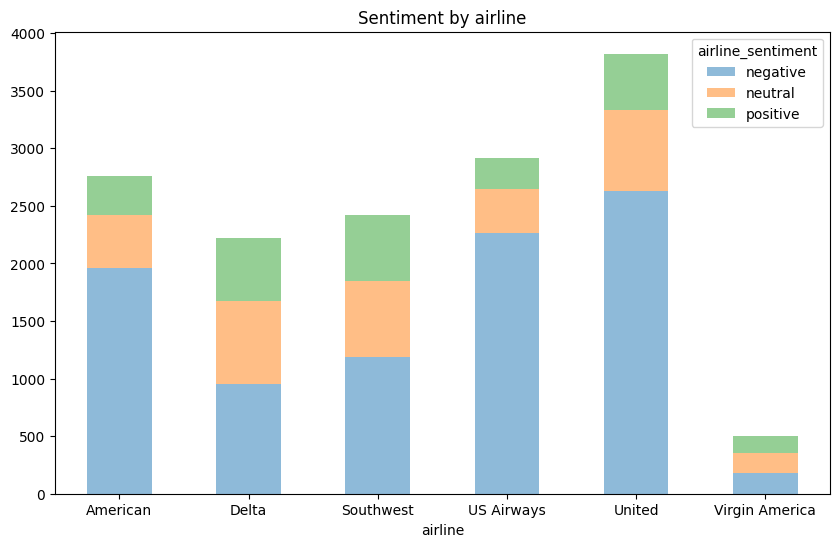

In [6]:
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiment by airline")

# Functions

In [7]:
import nltk
nltk.download('stopwords')
import re
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
stopwords_en = set(stopwords.words('english'))

In [9]:
def prepare_data(tweets):
    X = tweets['text']
    y = tweets['airline_sentiment'].map({'negative': -1, 'neutral': 0, 'positive': 1})
    return X, y

In [10]:
def count_total_words(text):
    total_words = text.str.split().apply(len).sum()
    return total_words

In [11]:
def clean_text(text):
    words = text.lower().split()
    words = [word for word in words if word not in stopwords_en and not word.startswith('@')]  # Delete stopwords and @users
    return ' '.join(words)

In [12]:
def train_and_evaluate_model(X_vec, y, test_size=0.2, random_state=42, n_estimators=100):

    X_train, X_test, Y_train, Y_test = train_test_split(X_vec, y, test_size=test_size, random_state=random_state)

    model = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, Y_pred)

    return {
        "model": model,
        "X_test": X_test,
        "Y_test": Y_test,
        "Y_pred": Y_pred,
        "accuracy": accuracy
    }

In [13]:
def display_predictions(model, X_test, Y_test, X_original, num_samples=30):
    test_indices = Y_test.index[:num_samples]

    predictions = model.predict(X_test[:num_samples])

    for i, idx in enumerate(test_indices):
        print(f"Tweet: {X_original.loc[idx]}")
        print(f"Actual Sentiment: {Y_test.loc[idx]}")
        print(f"Predicted Sentiment: {predictions[i]}")
        print("-" * 80)

# Exercise 1.1

Predict the sentiment using CountVectorizer

use Random Forest classifier

In [14]:
X, y = prepare_data(tweets)
print(f"Total words in X (original): {count_total_words(X)}")

Total words in X (original): 258446


In [15]:
count_vect = CountVectorizer()
X_vec = count_vect.fit_transform(X)

In [16]:
results = train_and_evaluate_model(X_vec, y)

# Accuracy
print(f"Model Accuracy: {results['accuracy']:.2f}")

Model Accuracy: 0.77


In [17]:
display_predictions(results['model'], results["X_test"], results["Y_test"], X, 10)

Tweet: @SouthwestAir you're my early frontrunner for best airline! #oscars2016
Actual Sentiment: 1
Predicted Sentiment: 1
--------------------------------------------------------------------------------
Tweet: @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: @JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: @JetBlue do they have to depart from Washington, D.C.??
Actual Sentiment: 0
Predicted Sentiment: 0
--------------------------------------------------------------------------------
Tweet: @JetBlue I can probably find some of them. Are the ticket #s on there?
Actual Sentiment: -1
Predicted Sent

# Exercise 1.2

Remove stopwords, then predict the sentiment using CountVectorizer.

use Random Forest classifier

In [18]:
X, y = prepare_data(tweets)
print(f"Total words in X (original): {count_total_words(X)}")

X_cleaned = X.apply(clean_text)
print(f"Total words in X_cleaned (without stopwords): {count_total_words(X_cleaned)}")

Total words in X (original): 258446
Total words in X_cleaned (without stopwords): 140133


In [19]:
count_vect = CountVectorizer()
X_vec_without_sw = count_vect.fit_transform(X_cleaned)

In [20]:
results_without_sw = train_and_evaluate_model(X_vec_without_sw, y)

# Accuracy
print(f"Model Accuracy: {results_without_sw['accuracy']:.2f}")

Model Accuracy: 0.78


In [21]:
display_predictions(results_without_sw['model'], results_without_sw["X_test"], results_without_sw["Y_test"], X_cleaned, 10)

Tweet: early frontrunner best airline! #oscars2016
Actual Sentiment: 1
Predicted Sentiment: 1
--------------------------------------------------------------------------------
Tweet: flt ewr cancelled flightled yet flts nyc usairways still flying?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: going bdl dca flights yesterday today?! every single one getting delayed?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: depart washington, d.c.??
Actual Sentiment: 0
Predicted Sentiment: 0
--------------------------------------------------------------------------------
Tweet: probably find them. ticket #s there?
Actual Sentiment: -1
Predicted Sentiment: 0
--------------------------------------------------------------------------------
Tweet: still waiting hear back. wallet stolen one planes would appreciate resolution
Actual Se

# Exercise 1.3

Increase n_grams size (with and without stopwords),  then predict the sentiment using CountVectorizer

use Random Forest classifier

# With Stopwords

In [22]:
X_grams, y_grams = prepare_data(tweets)
print(f"Total words in X (original): {count_total_words(X_grams)}")

Total words in X (original): 258446


In [23]:
count_vect = CountVectorizer(ngram_range=(1,3))
X_vec_grams = count_vect.fit_transform(X_grams)

In [24]:
results_grams = train_and_evaluate_model(X_vec_grams, y_grams)

# Accuracy
print(f"Model Accuracy: {results_grams['accuracy']:.2f}")

Model Accuracy: 0.76


In [25]:
display_predictions(results_grams['model'], results_grams["X_test"], results_grams["Y_test"], X_grams, 10)

Tweet: @SouthwestAir you're my early frontrunner for best airline! #oscars2016
Actual Sentiment: 1
Predicted Sentiment: 1
--------------------------------------------------------------------------------
Tweet: @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: @JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: @JetBlue do they have to depart from Washington, D.C.??
Actual Sentiment: 0
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: @JetBlue I can probably find some of them. Are the ticket #s on there?
Actual Sentiment: -1
Predicted Sen

# Without Stopwords

In [26]:
X, y = prepare_data(tweets)
print(f"Total words in X (original): {count_total_words(X)}")

X_cleaned_grams = X.apply(clean_text)
print(f"Total words in X_cleaned (without stopwords): {count_total_words(X_cleaned_grams)}")

Total words in X (original): 258446
Total words in X_cleaned (without stopwords): 140133


In [27]:
count_vect_grams = CountVectorizer(ngram_range=(1,3))
X_vec_without_sw_grams = count_vect_grams.fit_transform(X_cleaned_grams)

In [28]:
results_without_sw_grams = train_and_evaluate_model(X_vec_without_sw_grams, y)

# Accuracy
print(f"Model Accuracy: {results_without_sw_grams['accuracy']:.2f}")

Model Accuracy: 0.77


In [29]:
display_predictions(results_without_sw_grams['model'], results_without_sw_grams["X_test"], results_without_sw_grams["Y_test"], X_cleaned_grams, 10)

Tweet: early frontrunner best airline! #oscars2016
Actual Sentiment: 1
Predicted Sentiment: 1
--------------------------------------------------------------------------------
Tweet: flt ewr cancelled flightled yet flts nyc usairways still flying?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: going bdl dca flights yesterday today?! every single one getting delayed?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: depart washington, d.c.??
Actual Sentiment: 0
Predicted Sentiment: 0
--------------------------------------------------------------------------------
Tweet: probably find them. ticket #s there?
Actual Sentiment: -1
Predicted Sentiment: 0
--------------------------------------------------------------------------------
Tweet: still waiting hear back. wallet stolen one planes would appreciate resolution
Actual Se

# Exercise 1.4

Predict the sentiment using TfidfVectorizer.

use Random Forest classifier

In [30]:
X, y = prepare_data(tweets)
print(f"Total words in X (original): {count_total_words(X)}")

X_cleaned_tfidf = X.apply(clean_text)
print(f"Total words in X_cleaned (without stopwords): {count_total_words(X_cleaned_tfidf)}")

Total words in X (original): 258446
Total words in X_cleaned (without stopwords): 140133


# With Stopwords

In [31]:
tfidf = TfidfVectorizer()
X_vec_tfidf = tfidf.fit_transform(X)

#IDF for all words with stopwords in the vocabulary
print("IDF for all words in the vocabulary",tfidf.idf_)
print("-"*10)

IDF for all words in the vocabulary [7.88353089 7.15759389 9.89843391 ... 9.89843391 9.89843391 9.89843391]
----------


In [32]:
#With stopwords
results_tfidf = train_and_evaluate_model(X_vec_tfidf, y)
# Accuracy
print(f"Model Accuracy with stopwords: {results_tfidf['accuracy']:.2f}")

Model Accuracy with stopwords: 0.76


In [33]:
display_predictions(results_tfidf['model'], results_tfidf["X_test"], results_tfidf["Y_test"], X, 10)

Tweet: @SouthwestAir you're my early frontrunner for best airline! #oscars2016
Actual Sentiment: 1
Predicted Sentiment: 1
--------------------------------------------------------------------------------
Tweet: @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: @JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: @JetBlue do they have to depart from Washington, D.C.??
Actual Sentiment: 0
Predicted Sentiment: 0
--------------------------------------------------------------------------------
Tweet: @JetBlue I can probably find some of them. Are the ticket #s on there?
Actual Sentiment: -1
Predicted Sent

#Without stopwords

In [34]:
tfidf_sw = TfidfVectorizer()
X_vec_tfidf_sw = tfidf_sw.fit_transform(X_cleaned_tfidf)

#IDF for all words in the vocabulary
print("IDF for all words in the vocabulary",tfidf_sw.idf_)
print("-"*10)

IDF for all words in the vocabulary [7.88353089 7.15759389 9.89843391 ... 9.89843391 9.89843391 9.89843391]
----------


In [35]:
results_tfidf_sw = train_and_evaluate_model(X_vec_tfidf, y)
# Accuracy
print(f"Model Accuracy without stopwords: {results_tfidf['accuracy']:.2f}")

Model Accuracy without stopwords: 0.76


In [36]:
display_predictions(results_tfidf_sw['model'], results_tfidf_sw["X_test"], results_tfidf_sw["Y_test"], X_cleaned_tfidf, 10)

Tweet: early frontrunner best airline! #oscars2016
Actual Sentiment: 1
Predicted Sentiment: 1
--------------------------------------------------------------------------------
Tweet: flt ewr cancelled flightled yet flts nyc usairways still flying?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: going bdl dca flights yesterday today?! every single one getting delayed?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: depart washington, d.c.??
Actual Sentiment: 0
Predicted Sentiment: 0
--------------------------------------------------------------------------------
Tweet: probably find them. ticket #s there?
Actual Sentiment: -1
Predicted Sentiment: -1
--------------------------------------------------------------------------------
Tweet: still waiting hear back. wallet stolen one planes would appreciate resolution
Actual S

# **CONCLUSION**

The similar accuracy (0.76 - 0.78) across different approaches removing stopwords, using n-grams, and applying CountVectorizer or TfidfVectorizer makes sense because the dataset already contains clear sentiment indicators. The RandomForestClassifier is robust enough to learn patterns regardless of small text variations. Stopwords have minimal impact since key sentiment words remain, and n-grams provide slight improvements but do not drastically change performance. Likewise, TfidfVectorizer adjusts word importance but does not significantly enhance accuracy.